# Intro

## Global parameters

In [1]:
MAX_TIME_HOURS=1
ALPHA=0.01
_PVAL_FLOOR=10**-6

## Modules

### Standard

In [2]:
import os, pickle, platform, sys
import numpy as np
import torch

In [3]:
from collections import defaultdict

In [4]:
import dcms
from dcms.models import DCMModel, DECMModel, qDECMModel, DWCMModel

In [5]:
import matplotlib.pyplot as plt
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 2

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['ytick.minor.width'] = 1
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter

In [6]:
from scipy.stats import spearmanr

In [7]:
from tqdm.notebook import tqdm, trange

In [8]:
import datetime as dt

In [9]:
from bowtie import edges2bowtie

### Home made

In [10]:
if platform.system() == 'Darwin':
    print('Air!')
    HOME = '/Users/fabio/Documents/Lavoro/PythonFiles/bowtie2_py310/bowtie2/'
elif platform.system() == 'Linux':
    print('Stella!')
    HOME = '/home/sarawalk/bowtie2_py39/bowtie2/'
else:
    raise RuntimeError(f"Unsupported OS: {platform.system()}")

sys.path.insert(0, HOME)

Air!


In [11]:
from auxiliary_functions import el2ks, bic

In [12]:
from sam_bowtie import block_and_fluxes as bnf

In [13]:
from bowtie_plot_functions import plot_bowtie_blocks, plot_bowtie_fluxes, _add_colorbar
from bowtie_plot_functions import _fdr as fdr

## Load data

In [14]:
DATA_FOLDER=HOME+'dati_elezioni/'
TEST_FOLDER=HOME+'tests/'
PVALUE_FOLDER=HOME+'pvalues/'
GUARINO_FOLDER=HOME+'guarino_files/'
BIPARTITE_FOLDER=HOME+'BiDCM/'
PLOT_FOLDER=HOME+'plots/'

# Looking into the abyss

In [15]:
guarino_files=[file for file in os.listdir(GUARINO_FOLDER) if not file.startswith('.')]
guarino_files.sort()
guarino_files

['all_dico_labels.txt',
 'crisi_dico_0_bowtie_sizes.csv',
 'crisi_dico_1_bowtie_sizes.csv',
 'crisi_dico_2_bowtie_sizes.csv',
 'crisi_dico_3_bowtie_sizes.csv',
 'crisi_dico_4_bowtie_sizes.csv',
 'crisi_dico_labels.pickle',
 'ita_elections_dico_0_bowtie_sizes.csv',
 'ita_elections_dico_1_bowtie_sizes.csv',
 'ita_elections_dico_2_bowtie_sizes.csv',
 'ita_elections_dico_3_bowtie_sizes.csv',
 'ita_elections_dico_4_bowtie_sizes.csv',
 'ita_elections_dico_5_bowtie_sizes.csv',
 'ita_elections_dico_6_bowtie_sizes.csv',
 'ita_elections_dico_labels.pickle',
 'quirinale_dico_0_bowtie_sizes.csv',
 'quirinale_dico_1_bowtie_sizes.csv',
 'quirinale_dico_2_bowtie_sizes.csv',
 'quirinale_dico_3_bowtie_sizes.csv',
 'quirinale_dico_4_bowtie_sizes.csv',
 'quirinale_dico_5_bowtie_sizes.csv',
 'quirinale_dico_6_bowtie_sizes.csv',
 'quirinale_dico_labels.pickle']

In [16]:
bipartite_files=[file for file in os.listdir(BIPARTITE_FOLDER) if not file.startswith('.')]
bipartite_files.sort()
bipartite_files

['crisi_dico_0_bowtie_flows.csv',
 'crisi_dico_0_bowtie_sizes.csv',
 'crisi_dico_1_bowtie_flows.csv',
 'crisi_dico_1_bowtie_sizes.csv',
 'crisi_dico_2_bowtie_flows.csv',
 'crisi_dico_2_bowtie_sizes.csv',
 'crisi_dico_3_bowtie_flows.csv',
 'crisi_dico_3_bowtie_sizes.csv',
 'crisi_dico_4_bowtie_flows.csv',
 'crisi_dico_4_bowtie_sizes.csv',
 'ita_elections_dico_0_bowtie_flows.csv',
 'ita_elections_dico_0_bowtie_sizes.csv',
 'ita_elections_dico_1_bowtie_flows.csv',
 'ita_elections_dico_1_bowtie_sizes.csv',
 'ita_elections_dico_2_bowtie_flows.csv',
 'ita_elections_dico_2_bowtie_sizes.csv',
 'ita_elections_dico_3_bowtie_flows.csv',
 'ita_elections_dico_3_bowtie_sizes.csv',
 'ita_elections_dico_4_bowtie_flows.csv',
 'ita_elections_dico_4_bowtie_sizes.csv',
 'ita_elections_dico_5_bowtie_flows.csv',
 'ita_elections_dico_5_bowtie_sizes.csv',
 'ita_elections_dico_6_bowtie_flows.csv',
 'ita_elections_dico_6_bowtie_sizes.csv',
 'quirinale_dico_0_bowtie_flows.csv',
 'quirinale_dico_0_bowtie_sizes.cs

### Name of the various dicos

In [17]:
guarino_files[0]

'all_dico_labels.txt'

In [18]:
with open(GUARINO_FOLDER+guarino_files[0], 'r') as f:
    cacca=f.readlines()


In [19]:
def parse_dico_names(filepath):
    with open(filepath, 'r') as f:
        lines = [line.strip().split() for line in f]
        # such a command creates a list
        # in which each element is a list of tokens of a line in the file
        # remarkably, there is an empty element
        # before each dataset name
        

    result = {}
    current_key = None

    for tokens in lines:
        if not tokens:
            current_key = None
        elif current_key is None:
            # prima riga non vuota del gruppo: nome del dataset
            current_key = tokens[0]
            result[current_key] = {}
        else:
            # riga tipo ['5:', 'journalists', '&', 'Media']
            idx = int(tokens[0].rstrip(':'))
            label = ' '.join(tokens[1:])
            result[current_key][idx] = label

    return result

In [20]:
cacca=parse_dico_names(GUARINO_FOLDER+guarino_files[0])

In [21]:
cacca

{'quirinale': {5: 'journalists & Media',
  2: 'M5S',
  0: 'journalists & IV & Azione & +Europa & Media',
  4: 'Lega & FDI',
  1: 'PD',
  3: 'Media & journalists',
  6: 'FI'},
 'crisi': {1: 'Lega & FDI & FI',
  2: 'M5S & journalists',
  0: 'journalists & IV & Media & Azione & +Europa',
  4: 'Media & journalists',
  3: 'PD'},
 'ita_elections': {1: 'PD & Media & +Europa & journalists',
  2: 'M5S & Media',
  3: 'journalists & IV & Azione',
  0: 'Lega & FDI & FI',
  4: 'journalists & Media (1)',
  5: 'Media',
  6: 'journalists & Media (2)'}}

# Benchmarking: Ita_election

## Files

In [22]:
test_files=os.listdir(TEST_FOLDER)
test_files.sort()

In [23]:
elected_files=[file for file in test_files if file.startswith('ita')]
elected_files

['ita_elections_dico0_qdecm.pkl',
 'ita_elections_dico1_qdecm.pkl',
 'ita_elections_dico2_decm.pkl',
 'ita_elections_dico2_decm_0.pkl',
 'ita_elections_dico2_decm_final.pkl',
 'ita_elections_dico2_qdecm.pkl',
 'ita_elections_dico3_decm.pkl',
 'ita_elections_dico3_decm_final.pkl',
 'ita_elections_dico3_decm_final_0.pkl',
 'ita_elections_dico3_decm_final_1.pkl',
 'ita_elections_dico3_decm_stella.pkl',
 'ita_elections_dico3_dwcm_final.pkl',
 'ita_elections_dico3_dwcm_final_0.pkl',
 'ita_elections_dico3_dwcm_final_1.pkl',
 'ita_elections_dico3_dwcm_final_2.pkl',
 'ita_elections_dico3_qdecm.pkl',
 'ita_elections_dico4_qdecm.pkl',
 'ita_elections_dico5_qdecm.pkl',
 'ita_elections_dico6_qdecm.pkl']

In [24]:
for file in elected_files:
    if 'dico3' in file:
        try: 
            with open(TEST_FOLDER+file, 'rb') as f:
                cacca=pickle.load(f)
            file_name_friendly=file[14:25].strip('.')
            if 'stella' in file:
                print(f"{file_name_friendly}: Stella, MRE={cacca['sol'].mre:.2e}")
            elif cacca.sol.mre<10**-5:
                print(f"{file_name_friendly}: Ok, MRE={cacca.sol.mre:.2e}")
            else:
                print(f"{file_name_friendly}: Bad! MRE={cacca.sol.mre:.2e} ")
        except Exception as e:
            print(f"Error processing {file}: {e}")

    

dico3_decm: Bad! MRE=2.69e-03 
dico3_decm_: Bad! MRE=2.69e-03 
dico3_decm_: Bad! MRE=1.93e-03 
dico3_decm_: Bad! MRE=2.17e-04 
dico3_decm_: Stella, MRE=9.99e-06
dico3_dwcm_: Ok, MRE=1.07e-06
dico3_dwcm_: Ok, MRE=1.07e-06
dico3_dwcm_: Ok, MRE=1.07e-06
dico3_dwcm_: Ok, MRE=1.07e-06
dico3_qdecm: Ok, MRE=6.69e-06


In [25]:
ita_el_dict=defaultdict(dict)

for file in elected_files:
    dico=int(file.split('dico')[1][0])
    model=file.split('cm')[0].split('_')[-1]+'cm'
    try:
        with open(TEST_FOLDER+file, 'rb') as f:
            cacca=pickle.load(f)
    except Exception as e:
        print(f"Error loading {file}: {e}")
        continue
    if 'stella' in file:
        # stella was saved in a different format, so we skip it for now
        continue
    else:
        if cacca.sol.converged:
            if model=='dwcm':
                if 'dwcm_final_1' in file:
                    ita_el_dict[dico][model]=cacca
            else:
                ita_el_dict[dico][model]=cacca
        

##### Stella fix

In [27]:
stella_decm_file=[file for file in elected_files if 'stella' in file][0]
stella_decm_file

'ita_elections_dico3_decm_stella.pkl'

In [28]:
with open(TEST_FOLDER+stella_decm_file, 'rb') as f:
    cacca=pickle.load(f)

In [29]:
aux=(ita_el_dict[3]['qdecm'].k_out, ita_el_dict[3]['qdecm'].k_in, ita_el_dict[3]['qdecm'].s_out, ita_el_dict[3]['qdecm'].s_in)

In [30]:
ita_el_dict[3]['decm']=DECMModel(aux[0], aux[1], aux[2], aux[3])

In [31]:
ita_el_dict[3]['decm'].sol=cacca['sol']

In [32]:
stella_decm_file

'ita_elections_dico3_decm_stella.pkl'

In [33]:
elected_files

['ita_elections_dico0_qdecm.pkl',
 'ita_elections_dico1_qdecm.pkl',
 'ita_elections_dico2_decm.pkl',
 'ita_elections_dico2_decm_0.pkl',
 'ita_elections_dico2_decm_final.pkl',
 'ita_elections_dico2_qdecm.pkl',
 'ita_elections_dico3_decm.pkl',
 'ita_elections_dico3_decm_final.pkl',
 'ita_elections_dico3_decm_final_0.pkl',
 'ita_elections_dico3_decm_final_1.pkl',
 'ita_elections_dico3_decm_stella.pkl',
 'ita_elections_dico3_dwcm_final.pkl',
 'ita_elections_dico3_dwcm_final_0.pkl',
 'ita_elections_dico3_dwcm_final_1.pkl',
 'ita_elections_dico3_dwcm_final_2.pkl',
 'ita_elections_dico3_qdecm.pkl',
 'ita_elections_dico4_qdecm.pkl',
 'ita_elections_dico5_qdecm.pkl',
 'ita_elections_dico6_qdecm.pkl']

In [34]:
with open(TEST_FOLDER+'ita_elections_dico3_decm_final_2.pkl', 'wb') as f:
    pickle.dump(ita_el_dict[3]['decm'], f)

## Dico3

In [31]:
ita_el_dict[3].keys()

dict_keys(['dwcm', 'qdecm', 'decm'])

In [32]:
dwcm_theta=ita_el_dict[3]['dwcm'].sol.best_theta
qdecm_theta=ita_el_dict[3]['qdecm'].sol.best_theta
decm_theta=ita_el_dict[3]['decm'].sol.best_theta

In [33]:
N=len(dwcm_theta)//2
2*len(dwcm_theta)==len(qdecm_theta)

True

### Likelihood

In [34]:
dwcm_ll=ita_el_dict[3]['dwcm'].neg_log_likelihood(dwcm_theta)

In [35]:
qdecm_ll=ita_el_dict[3]['qdecm'].neg_log_likelihood_strength(qdecm_theta[:2*N], qdecm_theta[2*N:])
dcm_ll=DCMModel(aux[0], aux[1]).neg_log_likelihood(qdecm_theta[:2*N])
qdecm_ll+=dcm_ll

In [36]:
decm_ll=ita_el_dict[3]['decm'].neg_log_likelihood(decm_theta)

In [37]:
f'{dwcm_ll:.4e}, {qdecm_ll:.4e}, {decm_ll:.4e}'

'1.4260e+06, 1.2267e+06, 1.2309e+06'

In [38]:
f'best log-likelihood={max([-dwcm_ll, -qdecm_ll, -decm_ll]):.4e}'

'best log-likelihood=-1.2267e+06'

The best likelihood is the qDECM one! Therefore, if BIC does not select DWCM, it will necessarily select qDECM. How dare you?!

### BIC

In [39]:
dwcm_bic=ita_el_dict[3]['dwcm'].bic(dwcm_theta)
qdecm_bic=ita_el_dict[3]['qdecm'].bic(qdecm_theta[:2*N], qdecm_theta[2*N:])
decm_bic=ita_el_dict[3]['decm'].bic(decm_theta)


In [40]:
print(f'BIC(DWCM)={dwcm_bic:.3e}, BIC(QDECM)={qdecm_bic:.3e}, BIC(DECM)={decm_bic:.3e}')
print(f'Best BIC={min([dwcm_bic, qdecm_bic, decm_bic]):.3e}')

BIC(DWCM)=4.006e+06, BIC(QDECM)=4.761e+06, BIC(DECM)=4.770e+06
Best BIC=4.006e+06


HOW DARE YOU! 

### Calculation time

In [41]:
ita_el_dict[3]['dwcm'].sol.elapsed_time

2.3466509159989073

In [42]:
ita_el_dict[3]['qdecm'].sol.elapsed_time

72.22541045800244

DECM should be recalculated...

### Lagrangian multipliers comparison

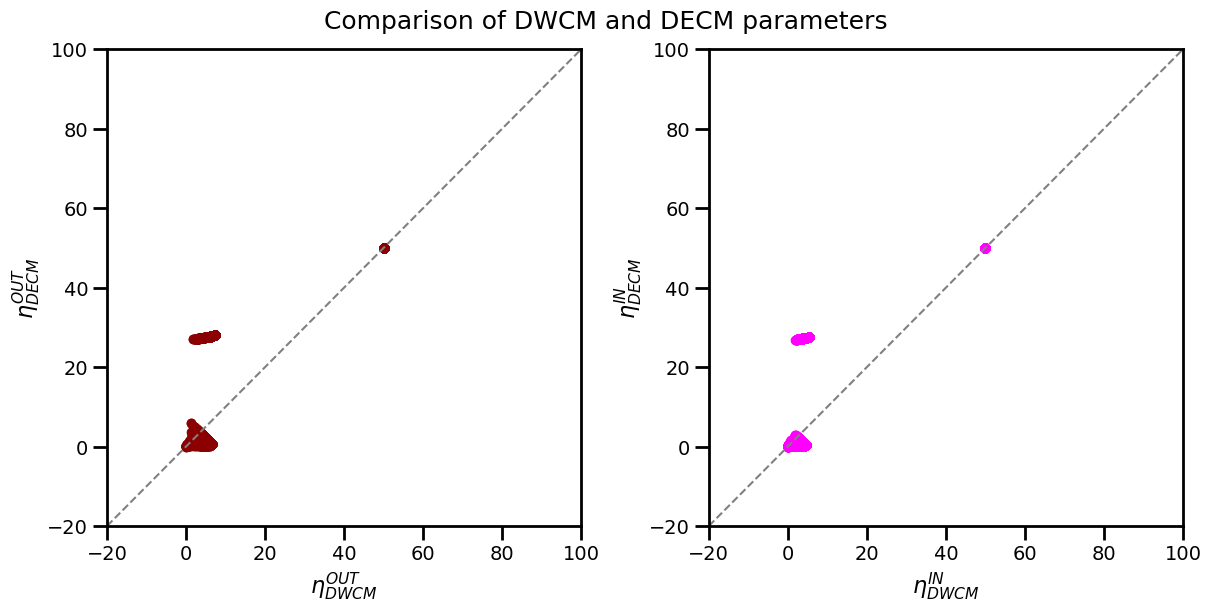

In [43]:
fig, axs= plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
colors=['darkred', 'magenta']
labels_dwcm=[r'$\eta^{OUT}_{DWCM}$', r'$\eta^{IN}_{DWCM}$']
labels_decm=[r'$\eta^{OUT}_{DECM}$', r'$\eta^{IN}_{DECM}$']
for i in range(2):
    _dwcm_theta=dwcm_theta[i*N:(i+1)*N]
    _decm_theta=decm_theta[(2+i)*N:(2+i+1)*N]
    axs[i].scatter(_dwcm_theta, _decm_theta, color=colors[i])
    axs[i].plot([-20,100], [-20,100], '--', color='gray')
    axs[i].set_xlim([-20, 100])
    axs[i].set_ylim([-20, 100])
    axs[i].set_xlabel(labels_dwcm[i ], fontsize=16)
    axs[i].set_ylabel(labels_decm[i], fontsize=16)
plt.suptitle('Comparison of DWCM and DECM parameters', fontsize=18)
plt.show()

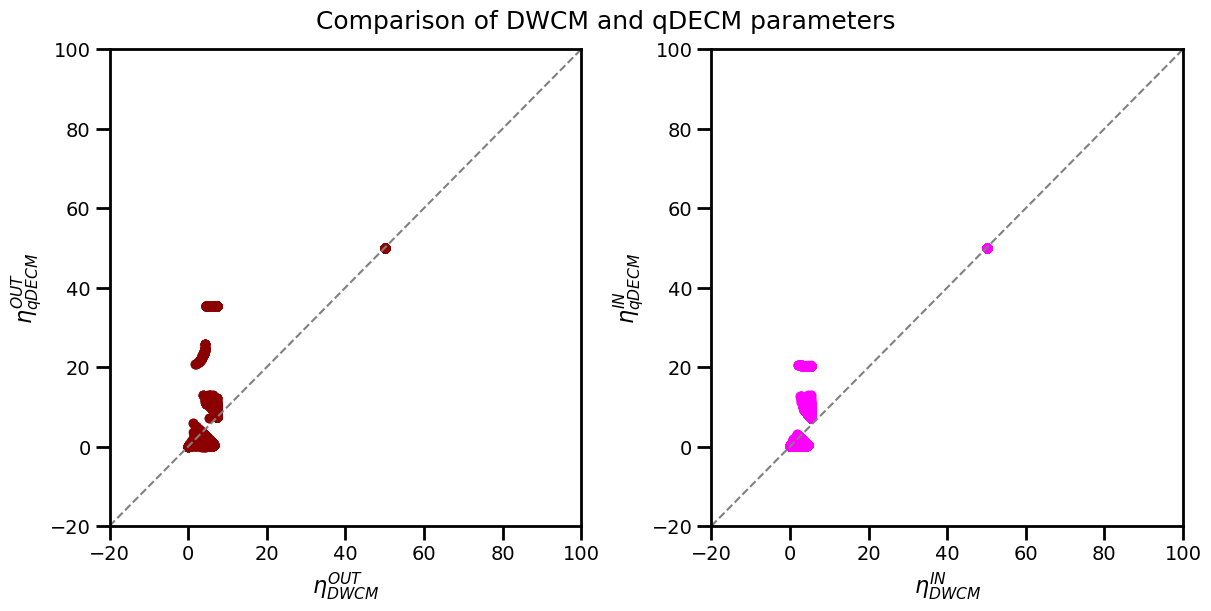

In [44]:
fig, axs= plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
colors=['darkred', 'magenta']
labels_dwcm=[r'$\eta^{OUT}_{DWCM}$', r'$\eta^{IN}_{DWCM}$']
labels_qdecm=[r'$\eta^{OUT}_{qDECM}$', r'$\eta^{IN}_{qDECM}$']
for i in range(2):
    _dwcm_theta=dwcm_theta[i*N:(i+1)*N]
    _qdecm_theta=qdecm_theta[(2+i)*N:(2+i+1)*N]
    axs[i].scatter(_dwcm_theta, _qdecm_theta, color=colors[i])
    axs[i].plot([-20,100], [-20,100], '--', color='gray')
    axs[i].set_xlim([-20, 100])
    axs[i].set_ylim([-20, 100])
    axs[i].set_xlabel(labels_dwcm[i ], fontsize=16)
    axs[i].set_ylabel(labels_qdecm[i], fontsize=16)
plt.suptitle('Comparison of DWCM and qDECM parameters', fontsize=18)
plt.show()

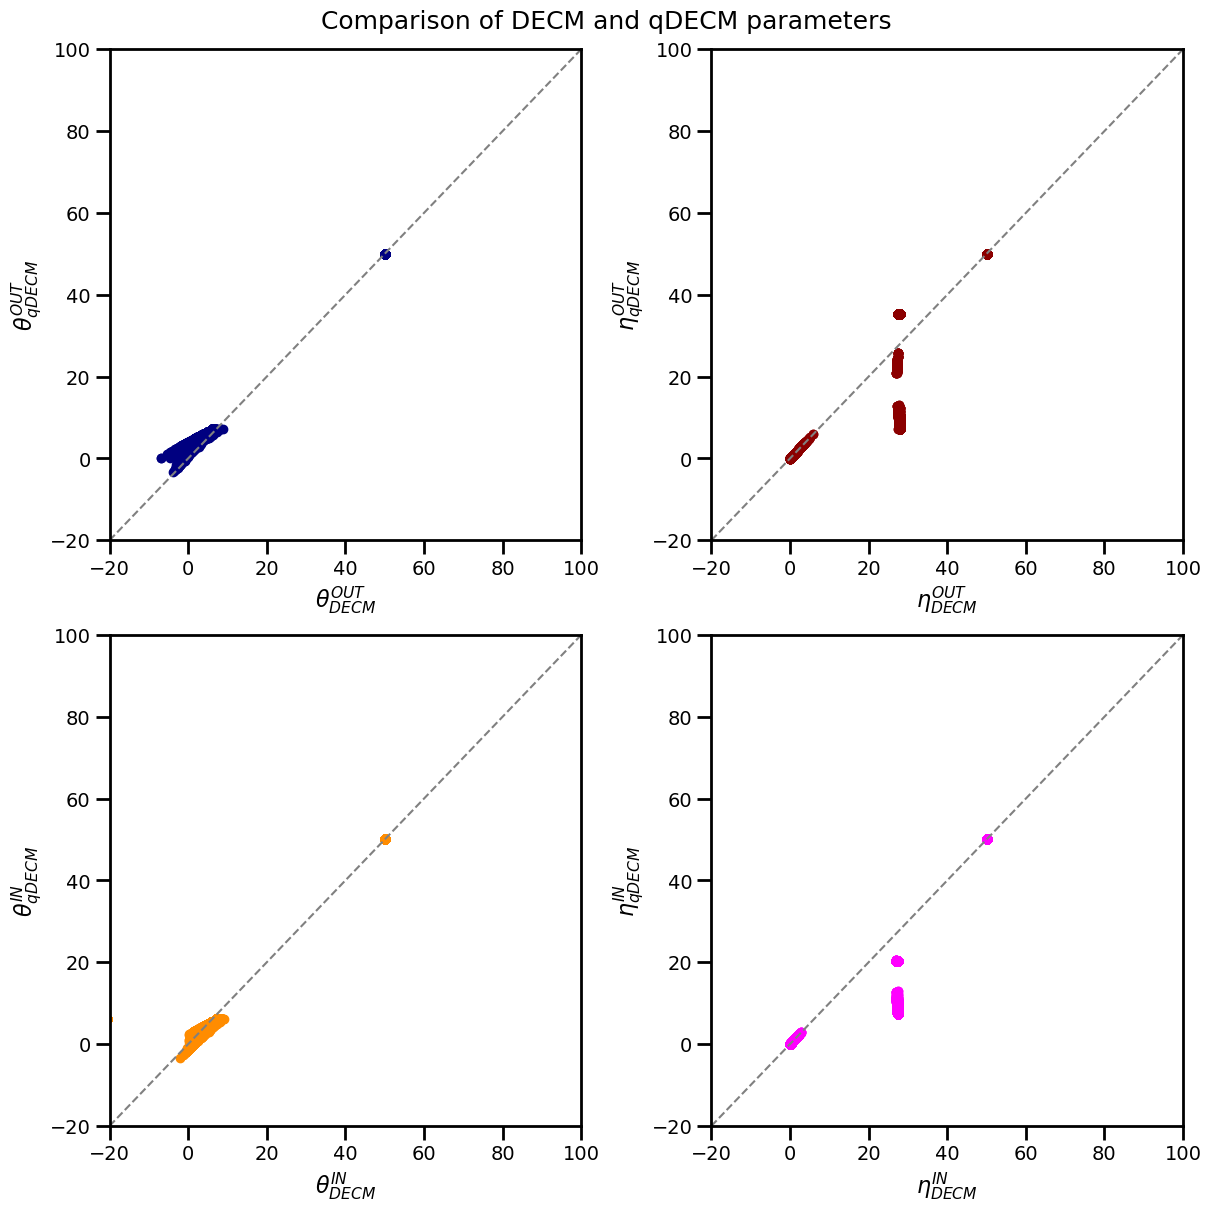

In [45]:
fig, axs= plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)
colors=['navy', 'darkorange', 'darkred', 'magenta']
labels_decm=[r'$\theta^{OUT}_{DECM}$', r'$\theta^{IN}_{DECM}$', r'$\eta^{OUT}_{DECM}$', r'$\eta^{IN}_{DECM}$']
labels_qdecm=[r'$\theta^{OUT}_{qDECM}$', r'$\theta^{IN}_{qDECM}$', r'$\eta^{OUT}_{qDECM}$', r'$\eta^{IN}_{qDECM}$']
for i in range(2):
    for j in range(2):
        _decm_theta=decm_theta[i*N+j*2*N:(i+1)*N+j*2*N]
        _qdecm_theta=qdecm_theta[i*N+j*2*N:(i+1)*N+j*2*N]
        axs[i, j].scatter(_decm_theta, _qdecm_theta, color=colors[i + 2*j])
        axs[i, j].plot([-20,100], [-20,100], '--', color='gray')
        axs[i, j].set_xlim([-20, 100])
        axs[i, j].set_ylim([-20, 100])
        axs[i, j].set_xlabel(labels_decm[i + 2*j], fontsize=16)
        axs[i, j].set_ylabel(labels_qdecm[i + 2*j], fontsize=16)
plt.suptitle('Comparison of DECM and qDECM parameters', fontsize=18)
plt.show()

### Probabilities and expected weights comparison

In [46]:
# Since the matrices are very large, we will sample a subset of the entries 
# to compare the probabilities.
sample_size=10**6
matrix_size=N*(N-1)/2
selected_points=np.random.choice(np.arange(matrix_size), size=sample_size, replace=False)

In [47]:
# colors and labels
colors=['orchid','darkcyan']
labels_decm=[r'$p_{DECM}$', r'$\langle w\rangle_{DECM}$']
labels_qdecm=[r'$p_{qDECM}$', r'$\langle w\rangle_{qDECM}$']
labels_dwcm=[r'$p_{DWCM}$', r'$\langle w\rangle_{DWCM}$']

#### Probability matrices

In [61]:
p_decm=ita_el_dict[3]['decm'].pij_matrix(ita_el_dict[3]['decm'].sol.theta).flatten()
p_decm=p_decm[selected_points]

In [62]:
p_qdecm=ita_el_dict[3]['qdecm'].pij_matrix(ita_el_dict[3]['qdecm'].sol.theta[:2*N]).flatten()
p_qdecm=p_qdecm[selected_points]

In [63]:
p_dwcm=ita_el_dict[3]['dwcm'].pij_matrix(ita_el_dict[3]['dwcm'].sol.theta).flatten()
p_dwcm=p_dwcm[selected_points]

In [64]:
#Check
len(p_dwcm)==len(p_qdecm)==len(p_decm)

True

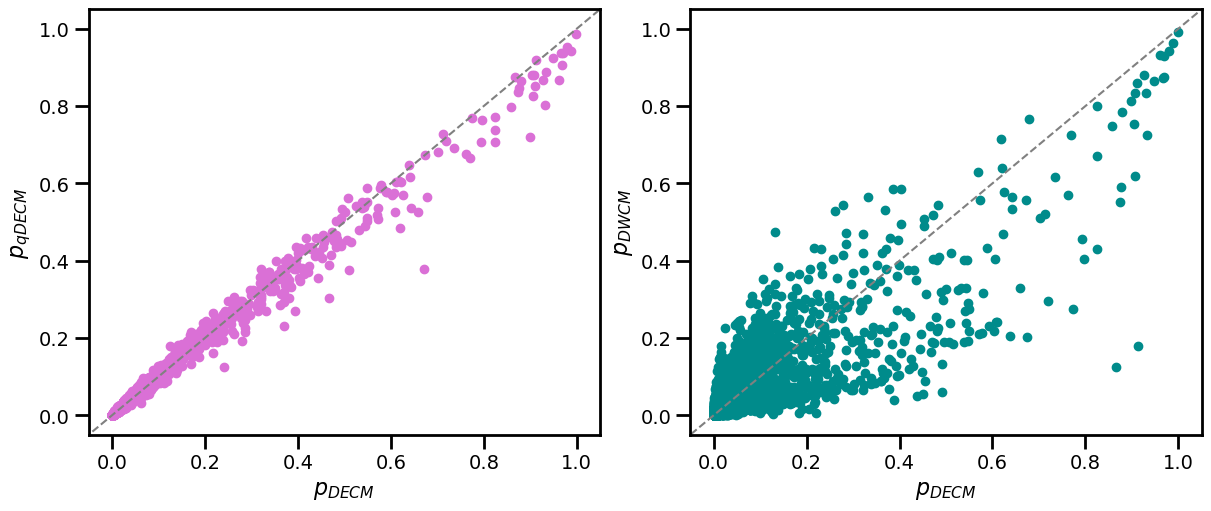

In [65]:
fig, axs= plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

axs[0].scatter(p_decm, p_qdecm, color=colors[0])
axs[0].plot([-1,2], [-1,2], '--', color='gray')
axs[0].set_xlim([-0.05, 1.05])
axs[0].set_ylim([-0.05, 1.05])

axs[1].scatter(p_decm, p_dwcm, color=colors[1])
axs[1].plot([-1,2], [-1,2], '--', color='gray')
axs[1].set_xlim([-0.05, 1.05])
axs[1].set_ylim([-0.05, 1.05])

    
for i in range(2):
    axs[i].set_xlabel(labels_decm[0], fontsize=16)
axs[0].set_ylabel(labels_qdecm[0], fontsize=16)
axs[1].set_ylabel(labels_dwcm[0], fontsize=16)
plt.show()

In [53]:
del p_decm, p_qdecm, p_dwcm

### Weight matrices

In [54]:
w_decm=ita_el_dict[3]['decm'].wij_matrix(ita_el_dict[3]['decm'].sol.theta).flatten()
w_decm=w_decm[selected_points]


In [55]:
w_qdecm=ita_el_dict[3]['qdecm'].wij_matrix_conditioned(ita_el_dict[3]['qdecm'].sol.theta[:2*N], ita_el_dict[3]['qdecm'].sol.theta[2*N:]).flatten()
w_qdecm=w_qdecm[selected_points]

In [56]:
w_dwcm=ita_el_dict[3]['dwcm'].wij_matrix(ita_el_dict[3]['dwcm'].sol.theta).flatten()
w_dwcm=w_dwcm[selected_points]

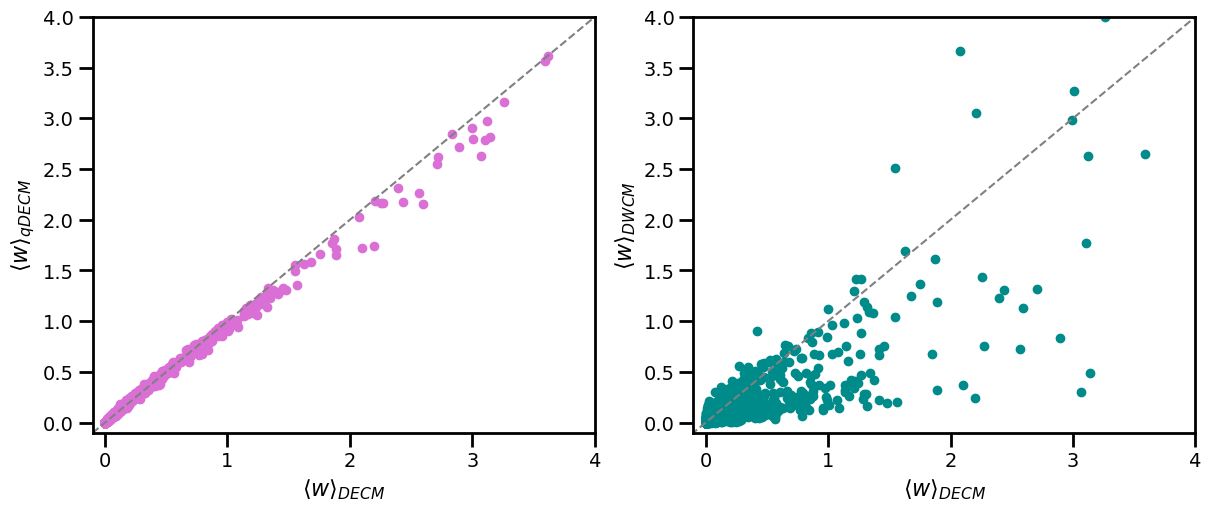

In [58]:
fig, axs= plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

axs[0].scatter(w_decm, w_qdecm, color=colors[0])
axs[0].plot([-1,10], [-1,10], '--', color='gray')
axs[0].set_xlim([-0.1, 4])
axs[0].set_ylim([-0.1, 4])

axs[1].scatter(w_decm, w_dwcm, color=colors[1])
axs[1].plot([-1,10], [-1,10], '--', color='gray')
axs[1].set_xlim([-0.1, 4])
axs[1].set_ylim([-0.1, 4])

for i in range(2):
    axs[i].set_xlabel(labels_decm[1], fontsize=16)
axs[0].set_ylabel(labels_qdecm[1], fontsize=16)
axs[1].set_ylabel(labels_dwcm[1], fontsize=16)
plt.show()

In [ ]:
del w_decm, w_qdecm, w_dwcm

## Maximum "error"

In [66]:
w_mask=w_decm>0
p_mask=p_decm>0

In [67]:
torch.all(p_mask==w_mask)

tensor(True)

In [68]:
w_mask.sum()

tensor(231469)

In [69]:
torch.all(p_qdecm[p_decm==0]==0)

tensor(True)

In [70]:
torch.all(w_qdecm[w_decm==0]==0)

tensor(True)

So, all the zero entries of p(DECM) are also zero according to qDECM. Good...

### Maximum absolute and relative error on $p$

In [71]:
abs_error_p=torch.abs(p_decm[w_mask]-p_qdecm[w_mask])
torch.max(abs_error_p)

tensor(0.2925, dtype=torch.float64)

In [72]:
where_max_abs_err_p=torch.where(abs_error_p==torch.max(abs_error_p))[0][0]

In [73]:
p_decm[w_mask][where_max_abs_err_p], p_qdecm[w_mask][where_max_abs_err_p]

(tensor(0.6712, dtype=torch.float64), tensor(0.3787, dtype=torch.float64))

In [74]:
torch.max(abs_error_p)/p_decm[w_mask][where_max_abs_err_p]

tensor(0.4358, dtype=torch.float64)

In [75]:
rel_error_p=torch.abs(p_decm[w_mask]-p_qdecm[w_mask])/p_decm[w_mask]
torch.max(rel_error_p)

tensor(6.0012, dtype=torch.float64)

In [76]:
where_max_rel_err_p=torch.where(rel_error_p==torch.max(rel_error_p))[0][0]

In [77]:
p_decm[w_mask][where_max_rel_err_p], p_qdecm[w_mask][where_max_rel_err_p]

(tensor(2.4479e-06, dtype=torch.float64),
 tensor(1.7138e-05, dtype=torch.float64))

In [78]:
abs_error_p[where_max_rel_err_p]

tensor(1.4690e-05, dtype=torch.float64)

### Maximum absolute and relative error on $w$

In [79]:
abs_error_w=torch.abs(w_decm[w_mask]-w_qdecm[w_mask])
torch.max(abs_error_w)

tensor(1.1620, dtype=torch.float64)

In [80]:
where_max_abs_err_w=torch.where(abs_error_w==torch.max(abs_error_w))[0][0]

In [81]:
w_decm[w_mask][where_max_abs_err_w], w_qdecm[w_mask][where_max_abs_err_w]

(tensor(8.1786, dtype=torch.float64), tensor(7.0166, dtype=torch.float64))

In [82]:
torch.max(abs_error_w)/w_decm[w_mask][where_max_abs_err_w]

tensor(0.1421, dtype=torch.float64)

In [83]:
rel_error_w=torch.abs(w_decm[w_mask]-w_qdecm[w_mask])/w_decm[w_mask]
torch.max(rel_error_w)

tensor(6.0012, dtype=torch.float64)

In [84]:
where_max_rel_err_w=torch.where(rel_error_w==torch.max(rel_error_w))[0][0]

In [85]:
w_decm[w_mask][where_max_rel_err_w], w_qdecm[w_mask][where_max_rel_err_w]

(tensor(2.4479e-06, dtype=torch.float64),
 tensor(1.7138e-05, dtype=torch.float64))

In [86]:
abs_error_w[where_max_rel_err_w]

tensor(1.4690e-05, dtype=torch.float64)

In [87]:
where_max_rel_err_w, where_max_rel_err_p

(tensor(14434), tensor(14434))

# Summarising
1. it seems that we have found a way out for DECM. Since I already told this multiple times, let us be more suspect. So far, we have a set of 3 real networks over which DECM converges, with some patience. DECM converges on every synthtetic powerlaw degree and strength distributed networks. 
2. on ita_elections_dico3 (i.e. our benchmark, as it is the one in which we **HAVE** a bowtie) BIC selects DWCM instead of the models informed about the topology (clearly "CM" in DCM stay for "Cane Maledetto"). Thus, waiting for months for the DECM to converge and then it is not selected as the best model. **HOW DARE YOU!?** Actually, as our measure is topological, we can restrict the model selection to the topology, i.e. comparing DWCM with DCM and DECM. Is it cheating? Probably it is, but let us postpone such a question to a future discussion.
3. **p-values obtained with the various models for the fluxes of between the blocks of the bowtie should be compared.**
4. <img src="disappointed-fan.gif" width="300" height="300">